Mean image distance: 59.068 mm
Std image distance:  1.939 mm


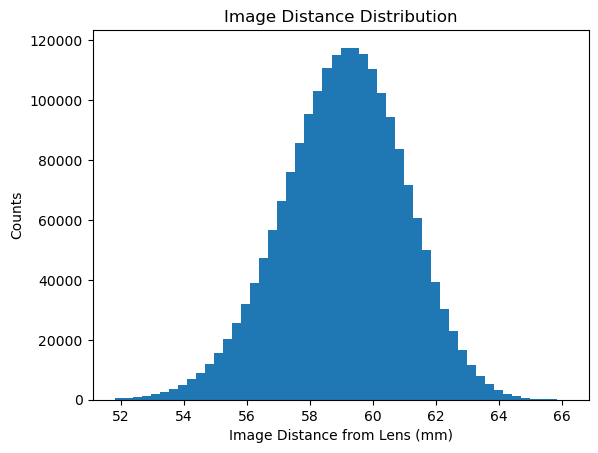

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def index_ref(wavelength, material):
    if material == 'MgF2':  # wavelength in um
        n_sqr = (1
               + 0.48755108*wavelength**2/(wavelength**2-0.04338408**2)
               + 0.39875031*wavelength**2/(wavelength**2-0.09461442**2)
               + 2.3120353*wavelength**2/(wavelength**2-23.793604**2))

    elif material == 'CaF2':  # wavelength in um
        n_sqr = (1
               + 0.33973
               + 0.69913*wavelength**2/(wavelength**2-0.09374**2)
               + 0.11994*wavelength**2/(wavelength**2-21.18**2)
               + 4.35181*wavelength**2/(wavelength**2-38.46**2))

    elif material == 'UVFS':  # wavelength in um
        n_sqr = (1
               + 0.6961663*wavelength**2/(wavelength**2-0.0684043**2)
               + 0.4079426*wavelength**2/(wavelength**2-0.1162414**2)
               + 2.8974794*wavelength**2/(wavelength**2-9.896161**2))
    else:
        raise ValueError("Unknown material")

    return n_sqr


def plano_convex_image_distance(
    wavelength_nm,
    material='UVFS',
    z_object_mm=10.565,
    z_lens_mm=1136.9,
    R_mm=34.39,
):
    wavelength_um = wavelength_nm * 1e-3
    n = np.sqrt(index_ref(wavelength_um, material))

    # thin-lens focal length for plano-convex in air
    f_mm = R_mm / (n - 1.0)

    # object distance from lens center
    s_obj_mm = z_lens_mm - z_object_mm

    # thin-lens image distance from lens
    s_img_mm = 1.0 / (1.0 / f_mm - 1.0 / s_obj_mm)

    return s_img_mm


# read only numeric lines from photons.csv
wavelengths_nm = []
with open("photons.csv", "r") as f:
    for line in f:
        try:
            wavelengths_nm.append(float(line.strip()))
        except:
            continue

wavelengths_nm = np.array(wavelengths_nm)

# compute image distances
image_distances_mm = np.array([
    plano_convex_image_distance(wl, material='UVFS')
    for wl in wavelengths_nm
])

print(f"Mean image distance: {np.mean(image_distances_mm):.3f} mm")
print(f"Std image distance:  {np.std(image_distances_mm):.3f} mm")

# histogram
plt.figure()
plt.hist(image_distances_mm, bins=50)
plt.xlabel("Image Distance from Lens (mm)")
plt.ylabel("Counts")
plt.title("Image Distance Distribution")
plt.show()

Chosen focus plane: 59.068 mm
Good-focus window: [58.068, 60.068] mm
In focus:  787181 / 2000000 (39.36%)
Out of focus: 1212819 / 2000000 (60.64%)


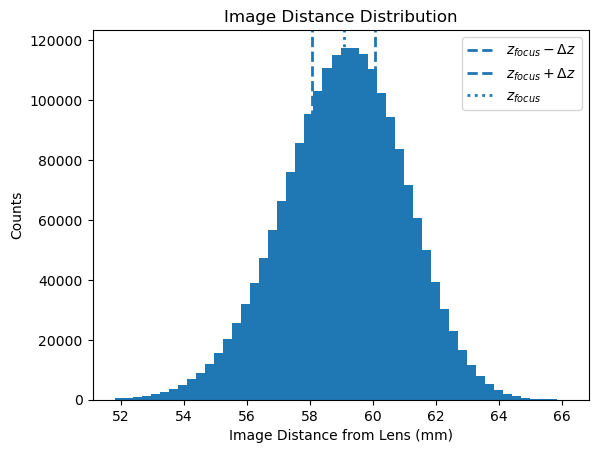

In [2]:
# ---------------------------------
# Define acceptable focus window
# ---------------------------------
delta_z = 1  # mm half-width for "good focus"
z_focus_mm = np.mean(image_distances_mm)   # or replace with your detector plane

z_low = z_focus_mm - delta_z
z_high = z_focus_mm + delta_z

in_focus_mask = (image_distances_mm >= z_low) & (image_distances_mm <= z_high)
out_focus_mask = ~in_focus_mask

n_total = len(image_distances_mm)
n_in_focus = np.count_nonzero(in_focus_mask)
n_out_focus = np.count_nonzero(out_focus_mask)

pct_in_focus = 100.0 * n_in_focus / n_total
pct_out_focus = 100.0 * n_out_focus / n_total

print(f"Chosen focus plane: {z_focus_mm:.3f} mm")
print(f"Good-focus window: [{z_low:.3f}, {z_high:.3f}] mm")
print(f"In focus:  {n_in_focus} / {n_total} ({pct_in_focus:.2f}%)")
print(f"Out of focus: {n_out_focus} / {n_total} ({pct_out_focus:.2f}%)")

# histogram
plt.figure()
plt.hist(image_distances_mm, bins=50)
plt.axvline(z_low, linestyle='--', linewidth=2, label=fr'$z_{{focus}}-\Delta z$')
plt.axvline(z_high, linestyle='--', linewidth=2, label=fr'$z_{{focus}}+\Delta z$')
plt.axvline(z_focus_mm, linestyle=':', linewidth=2, label=r'$z_{focus}$')

plt.xlabel("Image Distance from Lens (mm)")
plt.ylabel("Counts")
plt.title("Image Distance Distribution")
plt.legend()

ymax = plt.ylim()[1]

plt.show()

In [3]:
import numpy as np

HC_EV_NM = 1239.841984


def n_xe_ref_bideau_mehu(wavelength_um):
    lam_inv2 = 1.0 / (wavelength_um**2)

    n_minus_1 = (
        0.00322869 / (46.301 - lam_inv2)
        + 0.00355393 / (59.578 - lam_inv2)
        + 0.0606764 / (112.74 - lam_inv2)
    )

    return 1.0 + n_minus_1


def n_xe_gas(wavelength_um, pressure_bar=5.0, temperature_K=293.15):
    P_ref_bar = 1.01325
    T_ref_K = 273.15

    n_ref = n_xe_ref_bideau_mehu(wavelength_um)

    # Lorentz-Lorenz function at reference state
    L_ref = (n_ref**2 - 1.0) / (n_ref**2 + 2.0)

    # Ideal-gas density scaling
    density_ratio = (pressure_bar / P_ref_bar) * (T_ref_K / temperature_K)

    # Scale refractivity
    L = L_ref * density_ratio

    # Recover refractive index
    n = np.sqrt((1.0 + 2.0 * L) / (1.0 - L))
    return n


def index_ref(wavelength_um, material, pressure_bar=5.0, temperature_K=293.15):
    if material == 'MgF2':
        n_sqr = (
            1
            + 0.48755108 * wavelength_um**2 / (wavelength_um**2 - 0.04338408**2)
            + 0.39875031 * wavelength_um**2 / (wavelength_um**2 - 0.09461442**2)
            + 2.3120353  * wavelength_um**2 / (wavelength_um**2 - 23.793604**2)
        )
        return np.sqrt(n_sqr)

    elif material == 'CaF2':
        n_sqr = (
            1
            + 0.33973
            + 0.69913 * wavelength_um**2 / (wavelength_um**2 - 0.09374**2)
            + 0.11994 * wavelength_um**2 / (wavelength_um**2 - 21.18**2)
            + 4.35181 * wavelength_um**2 / (wavelength_um**2 - 38.46**2)
        )
        return np.sqrt(n_sqr)

    elif material == 'UVFS':
        n_sqr = (
            1
            + 0.6961663 * wavelength_um**2 / (wavelength_um**2 - 0.0684043**2)
            + 0.4079426 * wavelength_um**2 / (wavelength_um**2 - 0.1162414**2)
            + 0.8974794 * wavelength_um**2 / (wavelength_um**2 - 9.896161**2)
        )
        return np.sqrt(n_sqr)

    elif material == 'Xe':
        return n_xe_gas(
            wavelength_um,
            pressure_bar=pressure_bar,
            temperature_K=temperature_K
        )

    elif material == 'vacuum':
        return 1.0

    else:
        raise ValueError(f"Unknown material: {material}")


def plano_convex_image_position(
    energy_eV=None,
    wavelength_nm=None,
    material='UVFS',
    ambient='Xe',
    pressure_bar=5.0,
    temperature_K=293.15,
    z_obj_mm=None,
    z_V1_mm=None,   # first surface hit by light
    R1_mm=34.39,
    t_mm=12.5,
    debug=False
):

    wavelength_nm = HC_EV_NM / energy_eV
    wavelength_um = wavelength_nm * 1e-3

    n_lens = index_ref(
        wavelength_um, material,
        pressure_bar=pressure_bar,
        temperature_K=temperature_K
    )

    n_medium = index_ref(
        wavelength_um, ambient,
        pressure_bar=pressure_bar,
        temperature_K=temperature_K
    )

    # relative index for lens immersed in medium
    n_rel = n_lens / n_medium

    # effective focal length in medium
    f_mm = R1_mm / (n_rel - 1.0)

    # object distance from front principal plane
    s_mm = z_V1_mm - z_obj_mm

    # image distance from rear principal plane
    s_prime_mm = (f_mm * s_mm) / (s_mm - f_mm)

    # rear principal plane location
    z_H2_mm = z_V1_mm + t_mm - t_mm / n_rel

    # final image position
    z_img_mm = z_H2_mm + s_prime_mm

    if debug:
        print("----- Lens/Image Debug -----")
        print(f"wavelength_nm = {wavelength_nm:.6f}")
        print(f"wavelength_um = {wavelength_um:.9f}")
        print(f"n_lens        = {n_lens:.9f}")
        print(f"n_medium      = {n_medium:.9f}")
        print(f"n_rel         = {n_rel:.9f}")
        print(f"f_mm          = {f_mm:.6f}")
        print(f"s_mm          = {s_mm:.6f}")
        print(f"s_prime_mm    = {s_prime_mm:.6f}")
        print(f"z_H2_mm       = {z_H2_mm:.6f}")
        print(f"z_img_mm      = {z_img_mm:.6f}")
        print("----------------------------")

    return z_img_mm

In [4]:
z_img = plano_convex_image_position(
    energy_eV=2.0,
    material='UVFS',
    ambient='Xe',
    pressure_bar=5.0,
    temperature_K=293.15,
    z_obj_mm=-1120.085,
    z_V1_mm=-6.25,
    R1_mm=34.39,
    t_mm=12.5,
    debug=True
)

----- Lens/Image Debug -----
wavelength_nm = 619.920992
wavelength_um = 0.619920992
n_lens        = 1.457401791
n_medium      = 1.003160905
n_rel         = 1.452809597
f_mm          = 75.948037
s_mm          = 1113.835000
s_prime_mm    = 81.505583
z_H2_mm       = -2.354018
z_img_mm      = 79.151565
----------------------------
